
Dataset shape: (18909, 12)
Number of rows: 18909
Number of columns: 12

Column names: ['Course title', 'Skills', 'Organization', 'Ratings', 'Review count', 'Workload', 'Workload_Hour', 'Difficulty_level', 'Language', 'Course_link', 'Payment_Model', 'Course_Type']

Data types: Course title            str
Skills                  str
Organization            str
Ratings             float64
Review count          int64
Workload                str
Workload_Hour       float64
Difficulty_level        str
Language                str
Course_link             str
Payment_Model           str
Course_Type             str
dtype: object

Missing values:
                  Missing Count  Missing %
Course title                  0       0.00
Skills                        0       0.00
Organization                  0       0.00
Ratings                    9844      52.06
Review count                  0       0.00
Workload                   7660      40.51
Workload_Hour              7848      41.50
Difficulty_

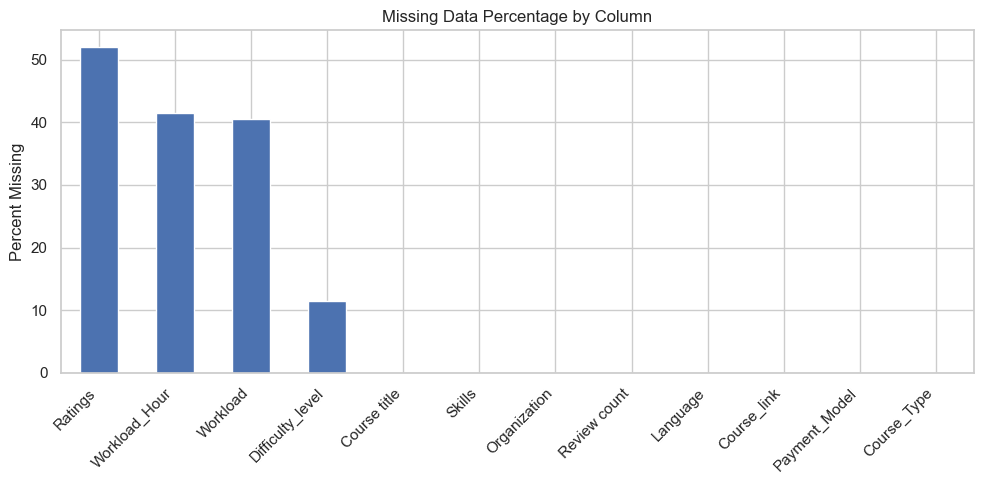

graph worked


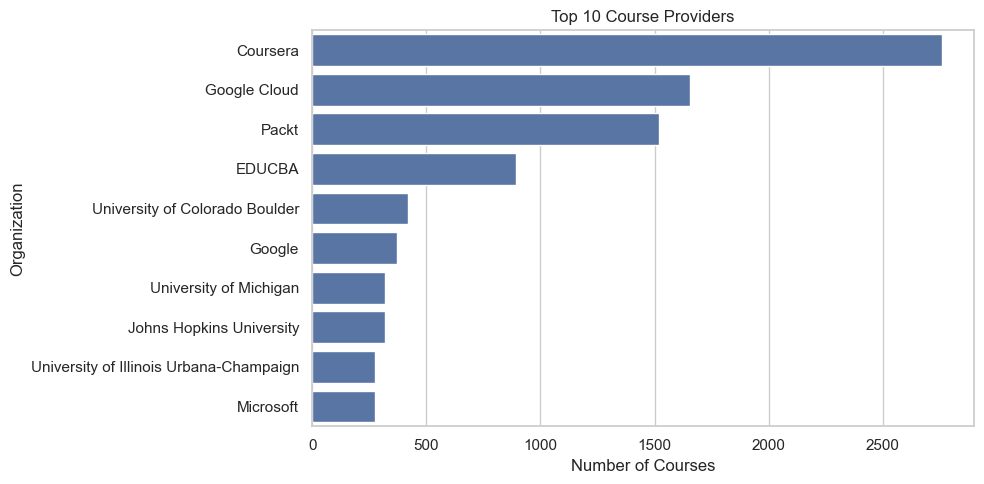

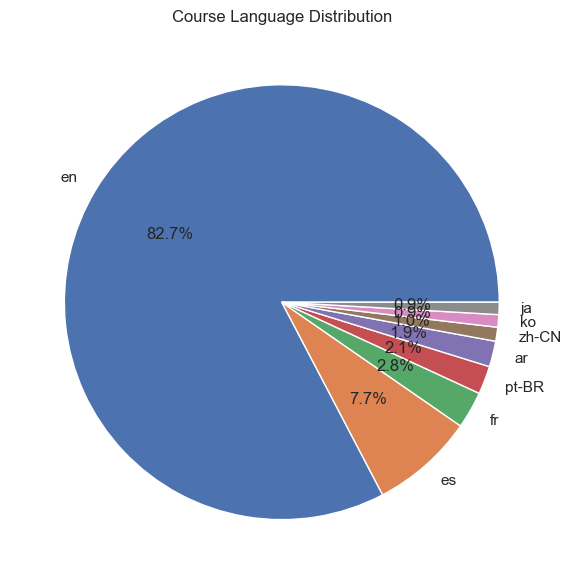

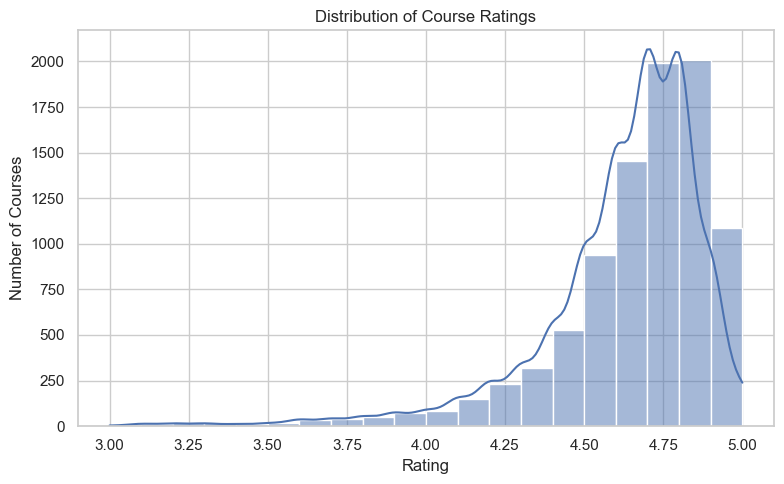


detect languages
:
lang_detected
tl         7660
af         4837
en         3005
pt          903
et          786
fr          687
ar          214
es          197
ko          119
de           91
id           59
sk           51
ru           49
nl           48
ro           46
unknown      36
zh-cn        32
cs           16
vi           14
so           12
bg           11
it           10
fi            8
fa            4
sw            3
ja            2
ca            2
sq            1
hi            1
cy            1
sv            1
pl            1
hu            1
th            1
Name: count, dtype: int64
detecting languages done
Workload_norm
2 hour                               942
1 hour                               630
1.5 hour                             236
4 week of study, 2-3 hour/week       131
90 minute                            118
4 hour                               118
3 hour                               111
45 minute                            101
4 week of study, 3-4 hour/wee

In [ ]:
### LOAD & INSPECT DATA
# checking coursera data
import numpy as np
import pandas as pd

# Load the data
df = pd.read_csv('/Users/era/Desktop/SPRING_2026/243_analytics_lab/AI_skills_roadmap/data/raw/skills/new_coursera_full_clean.csv')

# Check shapes of coursera dataset / inspect data
print(f"\nDataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

#column names

print('\nColumn names:', df.columns.tolist())
print('\nData types:', df.dtypes)

#inspect missing values
print('\nMissing values:', )
missing=df.isnull().sum()
missing_percent=(missing/len(df))*100

missing_table=pd.DataFrame({
    "Missing Count": missing, 
    "Missing %": missing_percent.round(2)
})

print(missing_table)

#inspect duplicates
duplicates=df.duplicated().sum()
print(f"\nNumber of duplicated rows: {duplicates}")

#numerical summary
print('\nNumerical Summary:', df.describe())

print('\nCategorical columns:')

categorical_cols=df.select_dtypes(exclude=[np.number]).columns
print("Categorical columns:", categorical_cols.tolist())

for col in categorical_cols:
    print(f"\nTop values for {col}:")
    print(df[col].value_counts().head(5))

print('\nUnique Values:')
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")



mostly_empty = missing_percent[missing_percent > 50]
if len(mostly_empty) > 0:
    print("\nColumns with >50% missing data:")
    print(mostly_empty)
else:
    print("\nNo columns have more than 50% missing data.")

print("\nEDA Completed Successfully!")


### VISUAL EDA GRAPHS (nulls, organizations, languages, ratings)
# ==============================
# VISUAL EDA SECTION
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ------------------------------
# 1. MISSING VALUES BAR CHART
# ------------------------------
plt.figure(figsize=(10,5))
missing_percent.sort_values(ascending=False).plot(kind="bar")
plt.title("Missing Data Percentage by Column")
plt.ylabel("Percent Missing")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("missing_values.png")
plt.show()
print('graph worked')


# ------------------------------
# 2. TOP ORGANIZATIONS
# ------------------------------
top_orgs = df["Organization"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_orgs.values, y=top_orgs.index)
plt.title("Top 10 Course Providers")
plt.xlabel("Number of Courses")
plt.ylabel("Organization")
plt.tight_layout()
plt.savefig("top_organizations.png")
plt.show()


# ------------------------------
# 3. LANGUAGE DISTRIBUTION
# ------------------------------
top_languages = df["Language"].value_counts().head(8)

plt.figure(figsize=(6,6))
plt.pie(top_languages.values, labels=top_languages.index, autopct='%1.1f%%')
plt.title("Course Language Distribution")
plt.tight_layout()
plt.savefig("language_distribution.png")
plt.show()


# ------------------------------
# 4. RATINGS DISTRIBUTION
# ------------------------------
ratings_clean = df["Ratings"].dropna()

plt.figure(figsize=(8,5))
sns.histplot(ratings_clean, bins=20, kde=True)
plt.title("Distribution of Course Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Courses")
plt.tight_layout()
plt.savefig("ratings_distribution.png")
plt.show()


# disregard # ------------------------------
# # 5. PRICE BREAKDOWN
# # ------------------------------
# price_counts = df["Price"].value_counts()

# plt.figure(figsize=(6,6))
# plt.pie(price_counts.values, labels=price_counts.index, autopct='%1.1f%%')
# plt.title("Free vs Subscription Courses")
# plt.tight_layout()
# plt.savefig("price_breakdown.png")
# plt.show()


# print("\nVisualizations saved to project folder!")


print('\ndetect languages\n:')

#detect languages
from langdetect import detect
import pandas as pd

def detect_lang(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

df["lang_detected"] = df["Workload"].astype(str).apply(detect_lang)
print(df["lang_detected"].value_counts())


print('detecting languages done')

#converting units across languages
unit_map = {
    # hours
    "hours":"hour","hour":"hour","hrs":"hour","hr":"hour",
    "horas":"hour","heure":"hour","heures":"hour","stunden":"hour",
    "ora":"hour","ore":"hour","小时":"hour","시간":"hour","ساعة":"hour",

    # weeks
    "weeks":"week","week":"week","semanas":"week","semaines":"week",
    "wochen":"week","semaine":"week","週":"week","주":"week",

    # months
    "months":"month","meses":"month","mois":"month","monate":"month",
    "月":"month",

    # minutes
    "minutes":"minute","mins":"minute","min":"minute","minutos":"minute",
    "分钟":"minute"
}

#normalize text
import re

def normalize_units(text):
    if pd.isna(text):
        return text
    
    text = text.lower()
    
    for word, replacement in unit_map.items():
        text = re.sub(rf'\b{word}\b', replacement, text)
    
    return text

df["Workload_norm"] = df["Workload"].apply(normalize_units)

print(df["Workload_norm"].value_counts().head(40))

print('inspecting workload done')


#convert word to number
word_to_num = {
    "one":"1","two":"2","three":"3","four":"4","five":"5",
    "six":"6","seven":"7","eight":"8","nine":"9","ten":"10",
    "eleven":"11","twelve":"12","thirteen":"13","fourteen":"14"
}

def replace_word_numbers(text):
    if pd.isna(text): return text
    text = text.lower()
    for w,n in word_to_num.items():
        text = re.sub(rf'\b{w}\b', n, text)
    return text

df["Workload_norm"] = df["Workload_norm"].apply(replace_word_numbers)

#normalize connectors 
def normalize_ranges(text):
    if pd.isna(text): return text
    text = re.sub(r'\s*(to|a|–|—|~)\s*', '-', text)
    return text

df["Workload_norm"] = df["Workload_norm"].apply(normalize_ranges)

#normalize phrases
def normalize_weekly(text):
    if pd.isna(text): return text
    text = re.sub(r'(per week|a week|weekly|por semana)', 'hour/week', text)
    return text

df["Workload_norm"] = df["Workload_norm"].apply(normalize_weekly)

#remove filler words
def remove_noise(text):
    if pd.isna(text): return text
    noise_words = [
        "about","approximately","approx","of study","de curso",
        "divididas em","course","contenido","conteudo"
    ]
    for w in noise_words:
        text = text.replace(w,"")
    return re.sub(r'\s+',' ',text).strip()

df["Workload_norm"] = df["Workload_norm"].apply(remove_noise)

print(df["Workload_norm"].value_counts().head(50), 'workload normalization done')


### Kyras code- count missing nulls (test if i get same results)
missing_count = []
for col in df.columns:
    null_count = df[col].isnull().sum()
    zero_count = ((df[col] == 0) | (df[col] == '0')).sum() if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'float64' else 0
    total_missing = null_count + zero_count
    missing_count.append({
        'Column': col,
        'Null_Count': null_count,
        'Zero_Count': zero_count,
        'Missing_Count': total_missing,
        'Missing_Percentage': round(total_missing / len(df) * 100, 2),
    })

missing_stats = pd.DataFrame(missing_count)
missing_stats = missing_stats.sort_values('Missing_Count', ascending=False)

print("\n" + "="*80)
print("Missing Values Statistics (Including 0 as Missing)")
print("="*80 + "\n")
print(missing_stats.to_string(index=False))
print('kyra code done, confirmed: missing counts match Kyra"s results')